In [1]:
from pathlib import Path

def find_project_root(start: Path, markers=("pyproject.toml", ".git")):
    for p in [start] + list(start.parents):
        if any((p / m).exists() for m in markers):
            return p
    raise RuntimeError("Project root not found")

ROOT = find_project_root(Path.cwd())

print(ROOT)

/home/urdatorn/git/gh/aristophanis-cantica


# Corpus

In [8]:
from aristophanis_cantica.stats import accentual_responsion_metric_corpus

accentual_responsion_stat = accentual_responsion_metric_corpus(ROOT / 'data/compiled')
acute_circumflex = accentual_responsion_stat['acute_circumflex']

print('WITH PL')
print(f'Acute-circumflex corpus metric: \033[92m{acute_circumflex}\033[0m')

accentual_responsion_stat = accentual_responsion_metric_corpus(ROOT / 'data/compiled/no_pl')
acute_circumflex = accentual_responsion_stat['acute_circumflex']

print('WITHOUT PL')
print(f'Acute-circumflex corpus metric: \033[92m{acute_circumflex}\033[0m')

WITH PL
Acute-circumflex corpus metric: 0.25639315098954857
WITHOUT PL
Acute-circumflex corpus metric: 0.2513029685021527


# Play regression

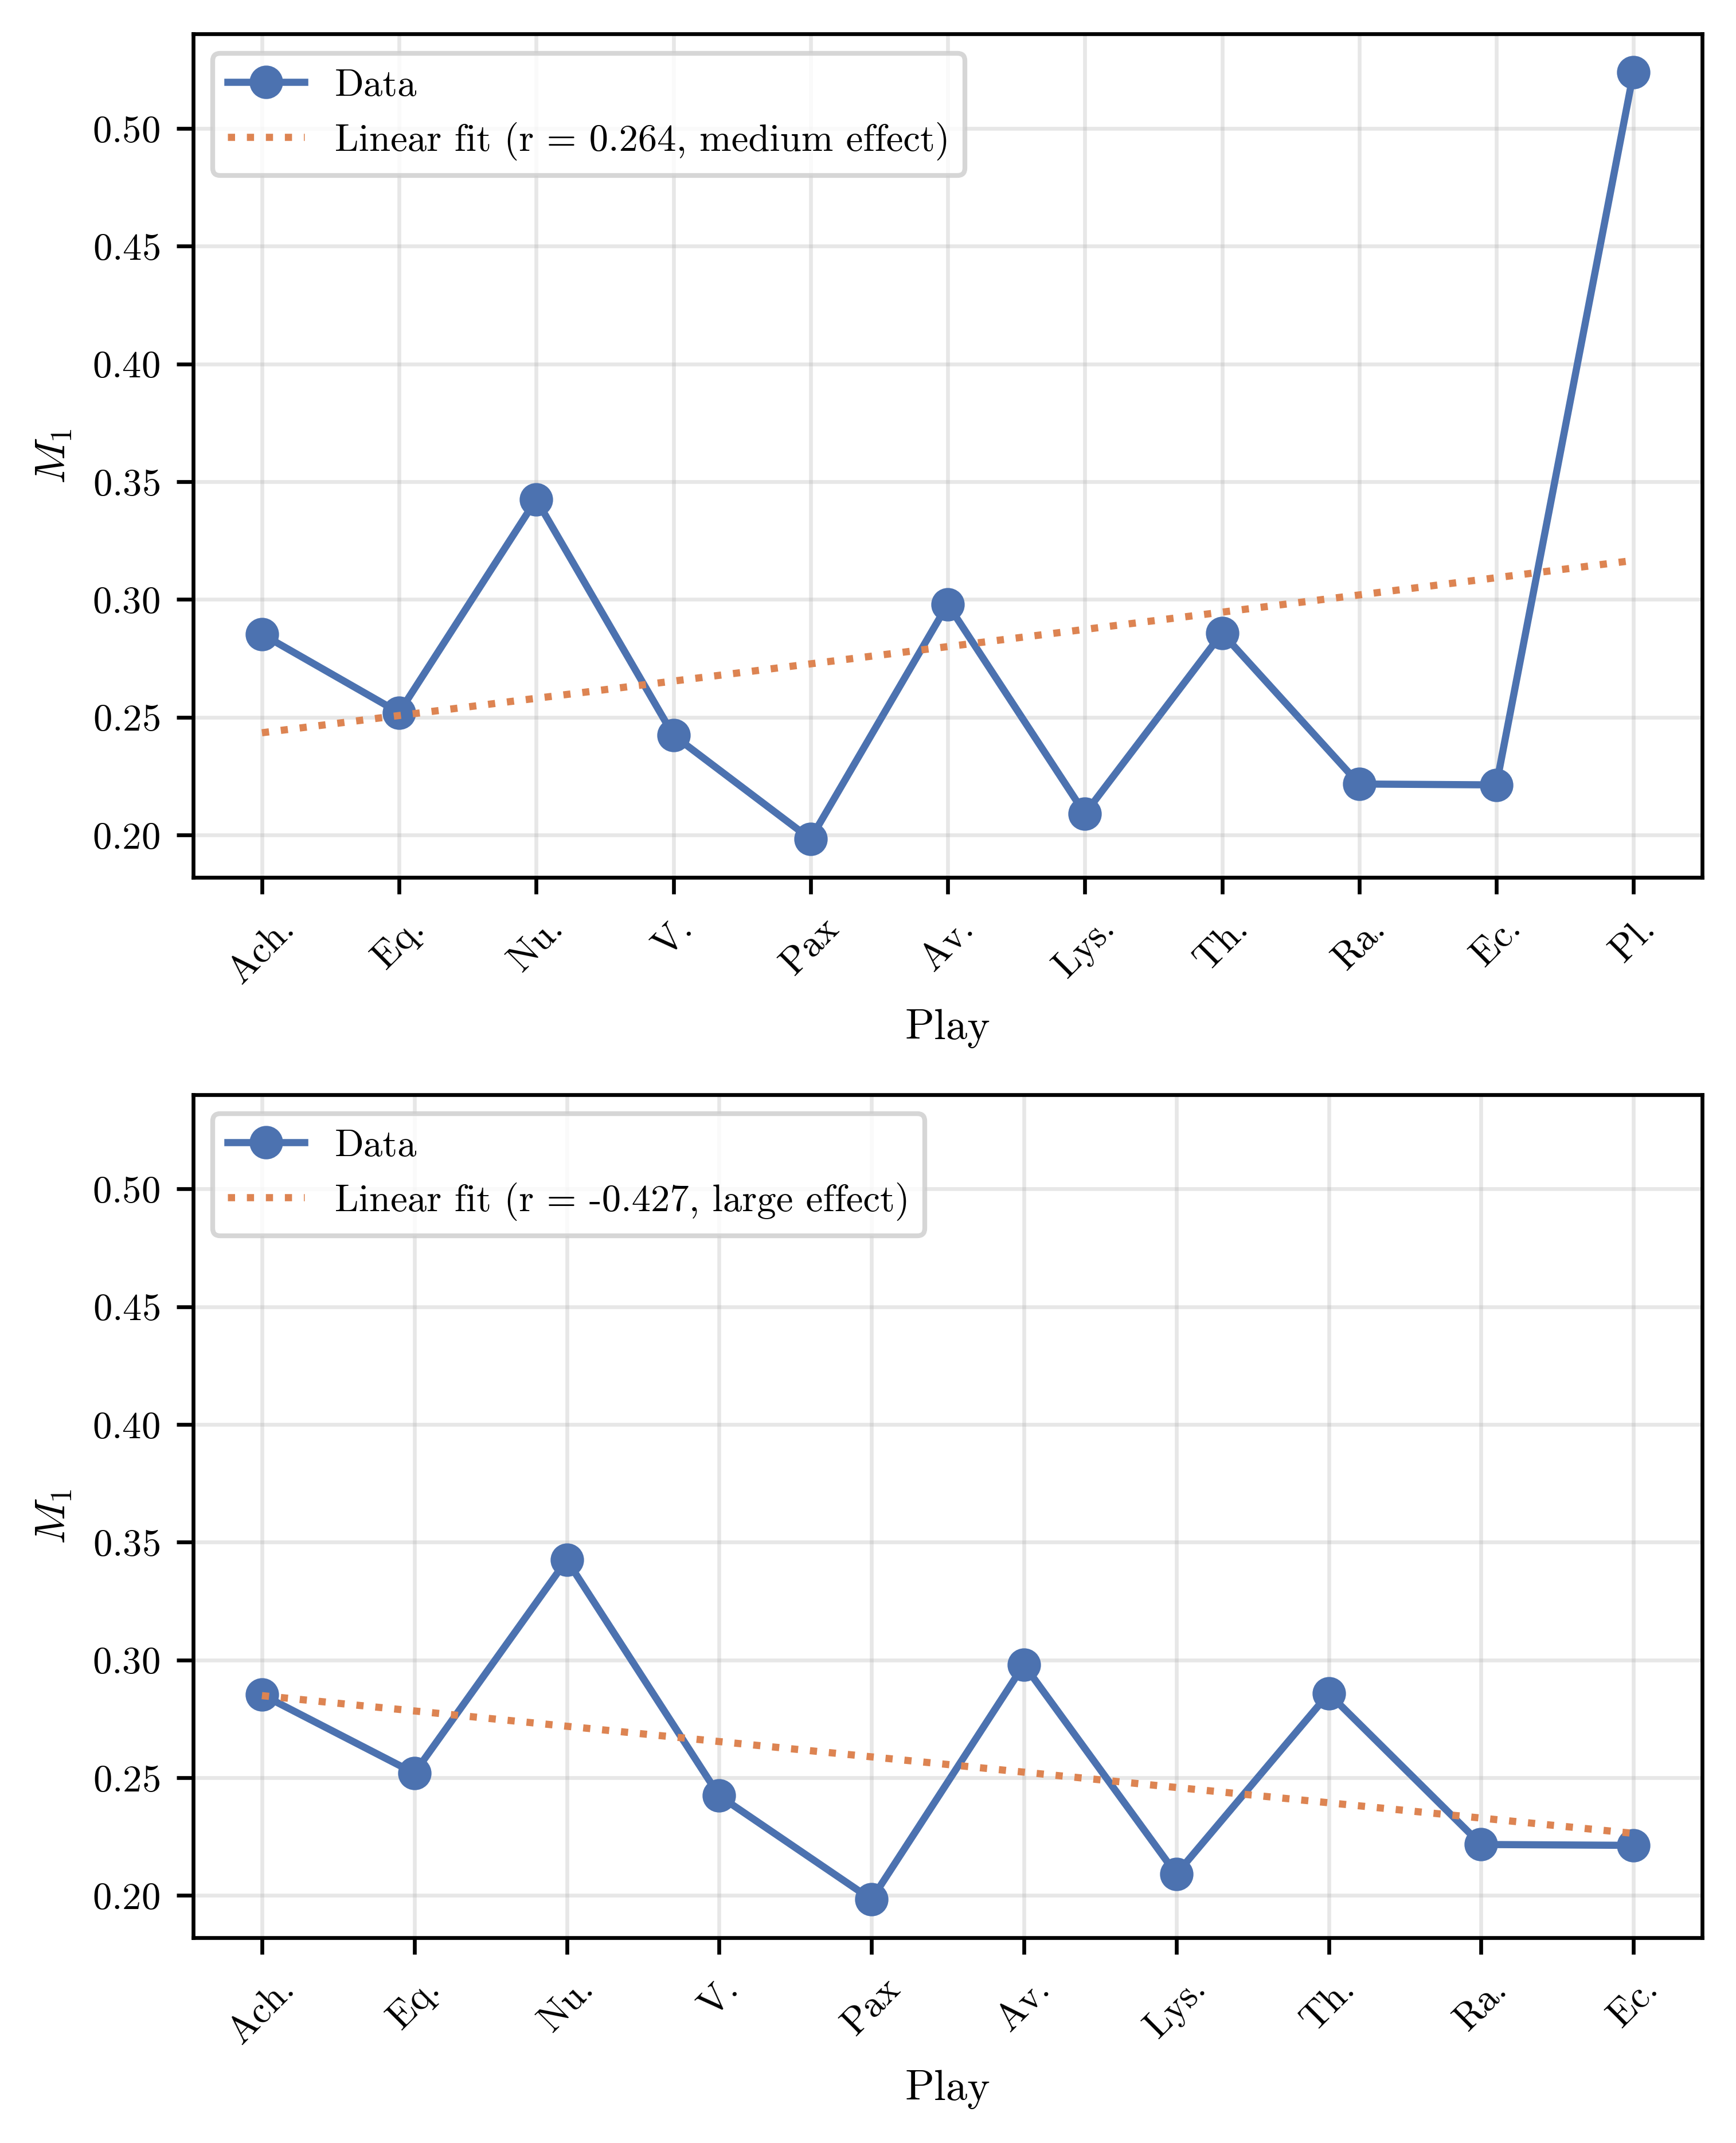

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

from aristophanis_cantica.plot import apply_plotting_poetry_palette_stacked
from aristophanis_cantica.stats import accentual_responsion_metric_play
from aristophanis_cantica.utils.utils import abbreviations, get_cohen_category, abbreviations_fancy

apply_plotting_poetry_palette_stacked()

abbreviations_no_pl = [abbrev for abbrev in abbreviations if abbrev != "pl"]

# ------------------------------------
# Settings
# ------------------------------------
metric = "acute_circumflex"
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]


# ------------------------------------
# Figure with two subplots
# ------------------------------------
fig, axes = plt.subplots(2, 1, sharey=True)


# ------------------------------------
# Top subplot: with Pl.
# ------------------------------------
play_stat_dictionary = {}

for play in abbreviations:
    xml_file = ROOT / f"data/compiled/responsion_{play}_compiled.xml"
    play_stat = accentual_responsion_metric_play(xml_file)
    play_stat_dictionary[play] = play_stat

data = play_stat_dictionary

x_labels = [abbreviations_fancy.get(k, k) for k in data]
x_numeric = np.arange(len(x_labels), dtype=float)
y_values = np.array([data[key][metric] for key in data], dtype=float)

slope, intercept, r_value, _, _ = linregress(x_numeric, y_values)
linear_fit = slope * x_numeric + intercept
cohen_category = get_cohen_category(r_value)

axes[0].plot(
    x_numeric,
    y_values,
    marker="o",
    color=default_colors[0],
    label="Data"
)

axes[0].plot(
    x_numeric,
    linear_fit,
    linestyle=":",
    color=default_colors[1],
    label=f"Linear fit (r = {r_value:.3f}, {cohen_category} effect)"
)

axes[0].set_xticks(x_numeric)
axes[0].set_xticklabels(x_labels, rotation=45)
axes[0].set_xlabel("Play")
axes[0].set_ylabel("$M_1$")
axes[0].grid(True, alpha=0.3)
axes[0].legend()


# ------------------------------------
# Bottom subplot: without Pl.
# ------------------------------------
play_stat_dictionary = {}

for play in abbreviations_no_pl:
    xml_file = ROOT / f"data/compiled/responsion_{play}_compiled.xml"
    play_stat = accentual_responsion_metric_play(xml_file)
    play_stat_dictionary[play] = play_stat

data = play_stat_dictionary

x_labels = [abbreviations_fancy.get(k, k) for k in data]
x_numeric = np.arange(len(x_labels), dtype=float)
y_values = np.array([data[key][metric] for key in data], dtype=float)

slope, intercept, r_value, _, _ = linregress(x_numeric, y_values)
linear_fit = slope * x_numeric + intercept
cohen_category = get_cohen_category(r_value)

axes[1].plot(
    x_numeric,
    y_values,
    marker="o",
    color=default_colors[0],
    label="Data"
)

axes[1].plot(
    x_numeric,
    linear_fit,
    linestyle=":",
    color=default_colors[1],
    label=f"Linear fit (r = {r_value:.3f}, {cohen_category} effect)"
)

axes[1].set_xticks(x_numeric)
axes[1].set_xticklabels(x_labels, rotation=45)
axes[1].set_xlabel("Play")
axes[1].set_ylabel("$M_1$")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper left")


plt.tight_layout()
plt.savefig(
    ROOT / "media/play_regression/linreg_orth.png",
    dpi=600
)
plt.show()